# CISC3024 AI Assignment #1 — MVP Notebook (v5, as executed)
## MobileNetV4 (mobilenetv4_conv_small) + CIFAR-10

> This is the notebook that produced the reported results, with the RNG
> resume fix applied. The cell outputs are the real Colab run.
## MobileNetV4 (mobilenetv4_conv_small) + CIFAR-10, transfer learning

**Recommended MVP** from `CISC3024_AI1_Algorithm_Survey_and_MVP_Plan.html`.

### What changed from v1
| # | Change | Why |
|---|--------|-----|
| 1 | Google Drive is mounted and `data_dir` points into it | CIFAR-10 downloads **once**, ever — Drive caches it across sessions |
| 2 | `out_dir` points into Drive | Checkpoints survive a Colab disconnect / VM recycle |
| 3 | `scheduler.step()` moved to **after** `optimizer.step()`, and is skipped when AMP skips the step | Removes the `lr_scheduler.step() before optimizer.step()` warning and stops the LR schedule drifting |
| 4 | Full resume: `optimizer`, `scheduler`, `scaler`, `epoch`, `best_acc`, `history`, RNG state | Restart the runtime and pick up exactly where you stopped |
| 5 | Atomic checkpoint writes (temp file + `os.replace`) | A disconnect mid-write can no longer corrupt your checkpoint |

### How to use this notebook in Colab
1. `Runtime -> Change runtime type -> T4 GPU` (free tier).
2. `Runtime -> Run all`, or step through the cells in order.
3. **Smoke test first:** set `img_size = 128`, `epochs = 2` in the config cell,
   confirm the whole pipeline runs, then switch back to `img_size = 224`,
   `epochs = 12` for the real run.
4. If Colab disconnects: just `Runtime -> Run all` again. The training cell
   detects `last.pt` on Drive and resumes automatically. Set `resume = False`
   in the config cell if you want to start over from scratch.

### Why these settings
MobileNetV4 weights are ImageNet-1k models at 224/256/384 px, but CIFAR-10 is
32x32. Feeding 32x32 directly collapses the feature map to 1x1 before the
classifier. So we **upsample to 224** and use the standard ImageNet
pre-processing protocol. This is the single most important engineering detail
in the whole pipeline.


## Stage 0 — Environment & GPU check

In [16]:
import sys, torch

print("Python :", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print("GPU  :", p.name)
    print("VRAM :", round(p.total_memory / 1024**3, 1), "GB")
else:
    print("!! No GPU detected.")
    print("   Colab: Runtime -> Change runtime type -> T4 GPU, then re-run.")

Python : 3.13.15
PyTorch: 2.11.0+cu128
CUDA available: True
GPU  : Tesla T4
VRAM : 14.6 GB


## Stage 0 — Install libraries

Record the printed `timm` version in your report so the run is reproducible.

In [17]:
!pip -q install timm torchmetrics

import timm
print("timm version:", timm.__version__, " <- pin this in your report")

timm version: 1.0.29  <- pin this in your report


## Stage 0 — Mount Google Drive and resolve persistent paths

**Change #1 and #2.** Everything that must outlive the Colab VM lives on Drive:

* the CIFAR-10 cache — downloaded exactly once, reused in every future session
* the run directory — checkpoints, curves, `results.json`

This cell also does a **write probe**: it fails loudly here, in 5 seconds, rather
than 40 minutes into training when the first checkpoint tries to save.

> **Note on Drive I/O.** CIFAR-10 is stored as six large pickle files that
> `torchvision` loads into memory in one shot, so reading it from Drive costs
> a few sequential reads — perfectly acceptable. If you later move to a dataset
> with thousands of tiny image files, copy it to `/content` (local SSD) first,
> because per-file Drive latency would dominate.


In [18]:
import os, sys, shutil
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    if not os.path.ismount("/content/drive"):
        drive.mount("/content/drive")
    DRIVE_ROOT = "/content/drive/MyDrive/cisc3024_ai1"
else:
    # Running locally (VS Code / Jupyter) — same layout, local disk.
    DRIVE_ROOT = os.path.abspath("./cisc3024_ai1")

DATA_DIR = os.path.join(DRIVE_ROOT, "data")                  # CIFAR-10 cache
OUT_DIR  = os.path.join(DRIVE_ROOT, "runs", "mnv4_cifar10")  # checkpoints, figures

for d in (DATA_DIR, OUT_DIR):
    Path(d).mkdir(parents=True, exist_ok=True)

print("running in Colab :", IN_COLAB)
print("DRIVE_ROOT       :", DRIVE_ROOT)
print("DATA_DIR         :", DATA_DIR)
print("OUT_DIR          :", OUT_DIR)

# --- write probe: fail fast if Drive is read-only or unmounted ---------------
probe = os.path.join(OUT_DIR, ".write_probe")
with open(probe, "w") as f:
    f.write("ok")
os.remove(probe)
print("write test       : OK")

# --- free space --------------------------------------------------------------
try:
    total, used, free = shutil.disk_usage(DRIVE_ROOT)
    print(f"drive space      : {free / 1024**3:.1f} GB free of {total / 1024**3:.1f} GB")
except Exception as e:
    print("drive space      : unavailable (", e, ")")

# --- is CIFAR-10 already cached? --------------------------------------------
_cifar_dir = os.path.join(DATA_DIR, "cifar-10-batches-py")
if os.path.isdir(_cifar_dir):
    print(f"cifar cache      : HIT ({len(os.listdir(_cifar_dir))} files) -> no download")
else:
    print("cifar cache      : MISS -> will download once (~170 MB) to Drive")

running in Colab : True
DRIVE_ROOT       : /content/drive/MyDrive/cisc3024_ai1
DATA_DIR         : /content/drive/MyDrive/cisc3024_ai1/data
OUT_DIR          : /content/drive/MyDrive/cisc3024_ai1/runs/mnv4_cifar10
write test       : OK
drive space      : 6.8 GB free of 15.0 GB
cifar cache      : HIT (8 files) -> no download


## Stage 0 — Imports, config, seed

**Change #1/#2:** `data_dir` and `out_dir` now come from the Drive cell above. `img_size`/`epochs` are back to the full-run values.

In [19]:
import os, json, time, random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torchvision
from torch.utils.data import DataLoader, Dataset
from torchvision import datasets, transforms

import timm

CFG = {
    # ---- paths: both live on Drive (see the mount cell above) --------------
    "drive_root":      DRIVE_ROOT,
    "data_dir":        DATA_DIR,   # CIFAR-10 cache -> downloaded once, ever
    "out_dir":         OUT_DIR,    # checkpoints    -> survive disconnects

    # ---- model -------------------------------------------------------------
    "model_name":      "mobilenetv4_conv_small.e2400_r224_in1k",
    "num_classes":     10,

    # ---- optimisation ------------------------------------------------------
    "img_size":        224,        # 128 for a fast smoke test, 224 for the real run
    "batch_size":      128,
    "epochs":          12,
    "lr":              3e-4,
    "weight_decay":    0.05,
    "label_smoothing": 0.1,
    "warmup_epochs":   1,

    # ---- runtime -----------------------------------------------------------
    "num_workers":     2,
    "val_frac":        0.10,
    "seed":            42,
    "amp":             True,
    "patience":        4,

    # ---- resume ------------------------------------------------------------
    "resume":          True,       # True -> continue from last.pt if it exists
}

def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(CFG["seed"])
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
Path(CFG["out_dir"]).mkdir(parents=True, exist_ok=True)

CKPT_LAST = os.path.join(CFG["out_dir"], "last.pt")   # full state -> resume
CKPT_BEST = os.path.join(CFG["out_dir"], "best.pt")   # best val acc -> final eval

print("device     :", device)
print("last ckpt  :", CKPT_LAST)
print("best ckpt  :", CKPT_BEST)

device     : cuda
last ckpt  : /content/drive/MyDrive/cisc3024_ai1/runs/mnv4_cifar10/last.pt
best ckpt  : /content/drive/MyDrive/cisc3024_ai1/runs/mnv4_cifar10/best.pt


## Stage 1 — Data pipeline

**Change #1.** `data_dir` is on Drive, so `torchvision` finds
`data_dir/cifar-10-batches-py` on the second run and skips the download entirely.

* **Train transform:** upscale -> random crop -> flip -> RandAugment -> normalise -> random erasing
* **Eval transform:** upscale -> centre crop -> normalise (deterministic)
* The 10 000-image **test set is held out** and only touched once, at the end.
* A 10 % validation split is carved out of the 50 000 training images.

The split uses a **fixed-seed generator**, so the same images land in
validation on every run — which is what makes resume and cross-run comparison valid.


In [20]:
MEAN, STD = (0.485, 0.456, 0.406), (0.229, 0.224, 0.225)
S = CFG["img_size"]
RESIZE = int(round(S * 256 / 224))   # ImageNet protocol: resize short side, then crop

train_tf = transforms.Compose([
    transforms.Resize(RESIZE),
    transforms.RandomCrop(S),
    transforms.RandomHorizontalFlip(),
    transforms.RandAugment(num_ops=2, magnitude=9),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.25, value="random"),
])

eval_tf = transforms.Compose([
    transforms.Resize(RESIZE),
    transforms.CenterCrop(S),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

# ---------------------------------------------------------------------------
# CIFAR-10 caching on Drive.
# torchvision's CIFAR10 checks for the extracted files under
#   data_dir/cifar-10-batches-py
# BEFORE it downloads. Pointing data_dir at Drive therefore means the archive
# is fetched exactly once and reused in every later session.
# ---------------------------------------------------------------------------
_cifar_dir = os.path.join(CFG["data_dir"], "cifar-10-batches-py")
print("CIFAR-10 cache:", "HIT -> skipping download" if os.path.isdir(_cifar_dir)
      else "MISS -> downloading once now")

base_train = datasets.CIFAR10(CFG["data_dir"], train=True,  download=True, transform=None)
base_test  = datasets.CIFAR10(CFG["data_dir"], train=False, download=True, transform=None)
print("cache after load:", "present" if os.path.isdir(_cifar_dir) else "MISSING (!!)")


class CifarWrap(Dataset):
    """Applies a transform to a (subset of a) CIFAR-10 dataset."""
    def __init__(self, base, tf, indices=None):
        self.base = base
        self.tf = tf
        self.indices = list(range(len(base))) if indices is None else list(indices)

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        img, y = self.base[self.indices[i]]
        return self.tf(img), y


# fixed seed -> identical train/val split on every run (required for resume)
g = torch.Generator().manual_seed(CFG["seed"])
perm = torch.randperm(len(base_train), generator=g).tolist()
n_val = int(len(base_train) * CFG["val_frac"])
val_idx, train_idx = perm[:n_val], perm[n_val:]

train_set = CifarWrap(base_train, train_tf, train_idx)
val_set   = CifarWrap(base_train, eval_tf,  val_idx)
test_set  = CifarWrap(base_test,  eval_tf)

CLASSES = base_test.classes
print(f"train {len(train_set)} | val {len(val_set)} | test {len(test_set)}")
print("classes:", CLASSES)

CIFAR-10 cache: HIT -> skipping download
cache after load: present
train 45000 | val 5000 | test 10000
classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


batch: (128, 3, 224, 224) | labels: [7, 4, 0, 1, 8, 1, 7, 6]


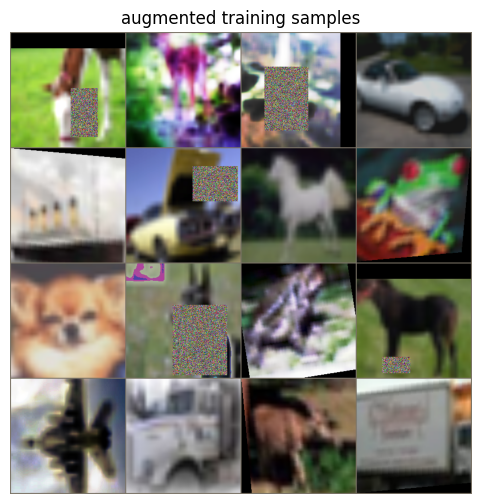

In [21]:
train_loader = DataLoader(train_set, batch_size=CFG["batch_size"], shuffle=True,
                          num_workers=CFG["num_workers"], pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_set, batch_size=256, shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)
test_loader  = DataLoader(test_set, batch_size=256, shuffle=False,
                          num_workers=CFG["num_workers"], pin_memory=True)

xb, yb = next(iter(train_loader))
print("batch:", tuple(xb.shape), "| labels:", yb[:8].tolist())

# visual sanity check: de-normalise a 4x4 grid
grid = torchvision.utils.make_grid(xb[:16], nrow=4, padding=2)
grid = grid * torch.tensor(STD).view(3, 1, 1) + torch.tensor(MEAN).view(3, 1, 1)
import matplotlib.pyplot as plt
plt.figure(figsize=(6, 6))
plt.imshow(grid.permute(1, 2, 0).clamp(0, 1))
plt.axis("off"); plt.title("augmented training samples"); plt.show()

## Stage 2 — Model assembly

One `timm.create_model` call. The `try/except` guards against a timm version that does not know the full weight tag.

In [22]:
def build_model():
    try:
        return timm.create_model(CFG["model_name"], pretrained=True,
                                 num_classes=CFG["num_classes"])
    except Exception as e:
        print("Full weight tag failed -> falling back to short name.")
        print("reason:", e)
        return timm.create_model("mobilenetv4_conv_small", pretrained=True,
                                 num_classes=CFG["num_classes"])

model = build_model().to(device)

n_all = sum(p.numel() for p in model.parameters())
n_tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"parameters: {n_all/1e6:.2f} M  (trainable: {n_tr/1e6:.2f} M)")

model.eval()
with torch.no_grad():
    out = model(torch.randn(2, 3, CFG["img_size"], CFG["img_size"], device=device))
print("output logits:", tuple(out.shape), "-> expect (2, 10)")
model.train()

parameters: 2.51 M  (trainable: 2.51 M)
output logits: (2, 10) -> expect (2, 10)


MobileNetV3(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): ReLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): ConvBnAct(
        (conv): Conv2d(32, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Identity()
      )
      (1): ConvBnAct(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): ReLU(inplace=True)
        )
        (aa): Identity()
        (drop_path): Iden

## Stage 3 — Loss, optimiser, schedule, AMP

AdamW with no weight decay on norms/biases, cosine annealing with a one-epoch warmup, label smoothing 0.1.

In [23]:
criterion = nn.CrossEntropyLoss(label_smoothing=CFG["label_smoothing"])

decay, no_decay = [], []
for _, p in model.named_parameters():
    if not p.requires_grad:
        continue
    (no_decay if p.ndim <= 1 else decay).append(p)

optimizer = torch.optim.AdamW(
    [{"params": decay,    "weight_decay": CFG["weight_decay"]},
     {"params": no_decay, "weight_decay": 0.0}],
    lr=CFG["lr"],
)

steps_per_epoch = len(train_loader)
total_steps  = CFG["epochs"] * steps_per_epoch
warmup_steps = CFG["warmup_epochs"] * steps_per_epoch

def lr_lambda(step):
    if step < warmup_steps:
        return (step + 1) / max(1, warmup_steps)
    prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
    return 0.5 * (1.0 + np.cos(np.pi * prog))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

USE_AMP = CFG["amp"] and device.type == "cuda"
try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
    def autocast_ctx():
        return torch.amp.autocast("cuda", dtype=torch.float16, enabled=USE_AMP)
except (TypeError, AttributeError):    # older PyTorch
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)
    def autocast_ctx():
        return torch.cuda.amp.autocast(enabled=USE_AMP)

print(f"steps/epoch {steps_per_epoch} | total {total_steps} | warmup {warmup_steps}")
print("mixed precision:", USE_AMP)

steps/epoch 351 | total 4212 | warmup 351
mixed precision: True


## Stage 3 — Train / evaluate functions

**Change #3 — the scheduler ordering fix.**

The order inside the loop is now, strictly:

```
1. optimizer.zero_grad()
2. scaler.scale(loss).backward()
3. scaler.unscale_(optimizer) + clip_grad_norm_
4. scaler.step(optimizer)      <-- optimizer.step() happens here
5. scaler.update()
6. scheduler.step()            <-- LAST, and only if step 4 actually ran
```

Why the guard matters: `GradScaler.step()` **skips** `optimizer.step()` whenever
it detects inf/NaN gradients, and halves the scale instead. Stepping the
scheduler unconditionally would

* trigger PyTorch's `Detected call of lr_scheduler.step() before optimizer.step()` warning, and
* advance the cosine schedule on a step that never happened, silently desynchronising the LR from the training progress.

Comparing `scaler.get_scale()` before the step against after `scaler.update()`
detects the skip: a decrease means the step was rejected, so the scheduler
stays put.


In [24]:
def train_one_epoch(model, loader, optimizer, criterion, scaler, scheduler, device):
    model.train()
    tot = correct = 0
    loss_sum = 0.0
    skipped_steps = 0

    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with autocast_ctx():
            logits = model(images)
            loss = criterion(logits, targets)

        # --- AMP + scheduler, in the correct order --------------------------
        scale_before = scaler.get_scale()

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)          # <- optimizer.step() happens here
        scaler.update()                 # <- may halve the scale on inf/NaN

        if scaler.get_scale() >= scale_before:
            scheduler.step()            # <- only after a real optimizer step
        else:
            skipped_steps += 1          # inf/NaN found -> step was rejected

        loss_sum += loss.item() * images.size(0)
        correct  += (logits.argmax(1) == targets).sum().item()
        tot      += images.size(0)

    if skipped_steps:
        print(f"    (note: {skipped_steps} step(s) skipped by GradScaler this epoch)")
    return loss_sum / tot, correct / tot


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    tot = correct = 0
    loss_sum = 0.0
    for images, targets in loader:
        images = images.to(device, non_blocking=True)
        targets = targets.to(device, non_blocking=True)
        with autocast_ctx():
            logits = model(images)
            loss = criterion(logits, targets)
        loss_sum += loss.item() * images.size(0)
        correct  += (logits.argmax(1) == targets).sum().item()
        tot      += images.size(0)
    return loss_sum / tot, correct / tot

## Stage 3 — Checkpointing & resume helpers

**Change #4 and #5.**

A checkpoint now carries *everything* needed to continue training bit-for-bit:
model, optimizer, scheduler, AMP scaler, epoch, best accuracy, early-stopping
counter, history, and the RNG states.

`atomic_save` writes to `<path>.tmp` and then calls `os.replace()`. That rename
is atomic on a single filesystem, so a disconnect in the middle of a write
leaves the previous good checkpoint intact instead of a truncated file that
`torch.load` would refuse. On Drive this is the difference between losing one
epoch and losing the whole run.

`safe_load` passes `weights_only=False` because the checkpoint contains Python
objects (the config dict, the history, the class list), not just tensors — and
it falls back gracefully on PyTorch versions whose `torch.load` does not accept
the argument.


In [25]:
def atomic_save(obj, path):
    """Write to a temp file, then atomically rename over the target."""
    tmp = path + ".tmp"
    torch.save(obj, tmp)
    os.replace(tmp, path)


def safe_load(path, map_location):
    """torch.load that tolerates the weights_only default change in PyTorch 2.6+."""
    try:
        return torch.load(path, map_location=map_location, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=map_location)


def save_checkpoint(path, epoch, model, optimizer, scheduler, scaler,
                    best_acc, bad_epochs, history):
    atomic_save({
        "epoch":      epoch,
        "model":      model.state_dict(),
        "optimizer":  optimizer.state_dict(),
        "scheduler":  scheduler.state_dict(),
        "scaler":     scaler.state_dict(),
        "best_acc":   best_acc,
        "bad_epochs": bad_epochs,
        "history":    history,
        "cfg":        CFG,
        "classes":    CLASSES,
        "rng": {
            "torch":  torch.get_rng_state(),
            "numpy":  np.random.get_state(),
            "python": random.getstate(),
        },
    }, path)


def load_checkpoint(path, model, optimizer, scheduler, scaler, device):
    """Restore full training state.

    Returns (start_epoch, best_acc, bad_epochs, history).
    """
    ckpt = safe_load(path, map_location=device)

    model.load_state_dict(ckpt["model"])
    optimizer.load_state_dict(ckpt["optimizer"])
    scheduler.load_state_dict(ckpt["scheduler"])
    if ckpt.get("scaler") is not None:
        try:
            scaler.load_state_dict(ckpt["scaler"])
        except Exception as e:
            print("  (scaler state not restored:", e, ")")

    rng = ckpt.get("rng")
    if rng:
        try:
            # torch.set_rng_state() only accepts a *contiguous CPU* ByteTensor
            # (ATen/core/Generator.h -> check_rng_state). safe_load() above uses
            # map_location=device, which moves EVERY tensor in the checkpoint onto
            # the GPU -- the RNG state included. It therefore has to be pinned back
            # to CPU here, or PyTorch raises "RNG state must be a torch.ByteTensor"
            # even though the dtype really is uint8. The old code also aborted on
            # the first line, so the numpy/python RNG states were never restored
            # either; each is now guarded independently.
            st = rng["torch"] if isinstance(rng, dict) else rng
            if not isinstance(st, torch.Tensor):
                st = torch.as_tensor(st)
            torch.set_rng_state(
                st.detach().to(device="cpu", dtype=torch.uint8).contiguous())
            if isinstance(rng, dict):
                if rng.get("numpy") is not None:
                    np.random.set_state(rng["numpy"])
                if rng.get("python") is not None:
                    random.setstate(rng["python"])
        except Exception as e:
            print("  (RNG state not restored:", e, ")")

    start_epoch = ckpt["epoch"] + 1
    return (start_epoch,
            ckpt.get("best_acc", 0.0),
            ckpt.get("bad_epochs", 0),
            ckpt.get("history"))

## Stage 3 — Training loop (resumable)

**Change #4.** If `last.pt` exists on Drive and `CFG["resume"]` is `True`, the
loop restores the full state and continues from `epoch + 1`. Otherwise it starts
from scratch.

Both checkpoints are written every epoch:

* `best.pt` — only when validation accuracy improves (used for the final test evaluation)
* `last.pt` — **always**, so a disconnect at any moment is recoverable

> **Gotcha:** the cosine schedule is built from `epochs * steps_per_epoch`. If you
> resume with a *different* `epochs` value than the original run, the LR curve
> changes shape. Keep `epochs` fixed across resumes — or set `resume = False` to
> start a genuinely new run.


In [26]:
history    = {k: [] for k in ("train_loss", "train_acc", "val_loss", "val_acc", "lr")}
best_acc   = 0.0
bad_epochs = 0
start_epoch = 1

# ---- resume if a previous run left a checkpoint ----------------------------
if CFG["resume"] and os.path.isfile(CKPT_LAST):
    print("found checkpoint:", CKPT_LAST)
    start_epoch, best_acc, bad_epochs, loaded_hist = load_checkpoint(
        CKPT_LAST, model, optimizer, scheduler, scaler, device)
    if loaded_hist:
        history = loaded_hist
    print(f"resumed -> next epoch {start_epoch}, best val acc {best_acc:.4f}, "
          f"lr {optimizer.param_groups[0]['lr']:.2e}")
elif CFG["resume"]:
    print("no checkpoint on Drive -> training from scratch")
else:
    print("CFG['resume'] = False -> training from scratch (existing checkpoints ignored)")

if start_epoch > CFG["epochs"]:
    print(f"\nnothing to do: the run already completed {CFG['epochs']} epochs.")
    print("Raise CFG['epochs'] to train further, or set CFG['resume']=False to restart.")

# ---- main loop -------------------------------------------------------------
for epoch in range(start_epoch, CFG["epochs"] + 1):
    t0 = time.time()
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion,
                                      scaler, scheduler, device)
    va_loss, va_acc = evaluate(model, val_loader, criterion, device)
    dt = time.time() - t0
    lr = optimizer.param_groups[0]["lr"]

    for k, v in zip(("train_loss", "train_acc", "val_loss", "val_acc", "lr"),
                    (tr_loss, tr_acc, va_loss, va_acc, lr)):
        history[k].append(v)

    flag = ""
    if va_acc > best_acc:
        best_acc, bad_epochs, flag = va_acc, 0, "   <- best"
        save_checkpoint(CKPT_BEST, epoch, model, optimizer, scheduler, scaler,
                        best_acc, bad_epochs, history)
    else:
        bad_epochs += 1

    # always refresh last.pt: a disconnect now costs at most one epoch
    save_checkpoint(CKPT_LAST, epoch, model, optimizer, scheduler, scaler,
                    best_acc, bad_epochs, history)

    print(f"epoch {epoch:2d}/{CFG['epochs']} | "
          f"train {tr_loss:.4f} acc {tr_acc:.4f} | "
          f"val {va_loss:.4f} acc {va_acc:.4f} | "
          f"lr {lr:.2e} | {dt:5.1f}s{flag}")

    if bad_epochs >= CFG["patience"]:
        print(f"early stopping at epoch {epoch} (no val improvement for "
              f"{CFG['patience']} epochs)")
        break

print("best validation accuracy:", round(best_acc, 4))
print("best ckpt:", CKPT_BEST)
print("last ckpt:", CKPT_LAST)

found checkpoint: /content/drive/MyDrive/cisc3024_ai1/runs/mnv4_cifar10/last.pt
  (RNG state not restored: RNG state must be a torch.ByteTensor )
resumed -> next epoch 8, best val acc 0.9508, lr 1.30e-04
epoch  8/12 | train 0.6128 acc 0.9570 | val 0.6043 acc 0.9594 | lr 8.86e-05 | 171.6s   <- best
epoch  9/12 | train 0.5849 acc 0.9693 | val 0.5948 acc 0.9614 | lr 5.25e-05 | 158.2s   <- best
epoch 10/12 | train 0.5656 acc 0.9788 | val 0.5885 acc 0.9652 | lr 2.43e-05 | 156.1s   <- best
epoch 11/12 | train 0.5517 acc 0.9851 | val 0.5869 acc 0.9670 | lr 6.35e-06 | 156.4s   <- best
epoch 12/12 | train 0.5439 acc 0.9883 | val 0.5873 acc 0.9660 | lr 3.18e-09 | 156.2s
best validation accuracy: 0.967
best ckpt: /content/drive/MyDrive/cisc3024_ai1/runs/mnv4_cifar10/best.pt
last ckpt: /content/drive/MyDrive/cisc3024_ai1/runs/mnv4_cifar10/last.pt


## Stage 4 — Curves, test evaluation, confusion matrix

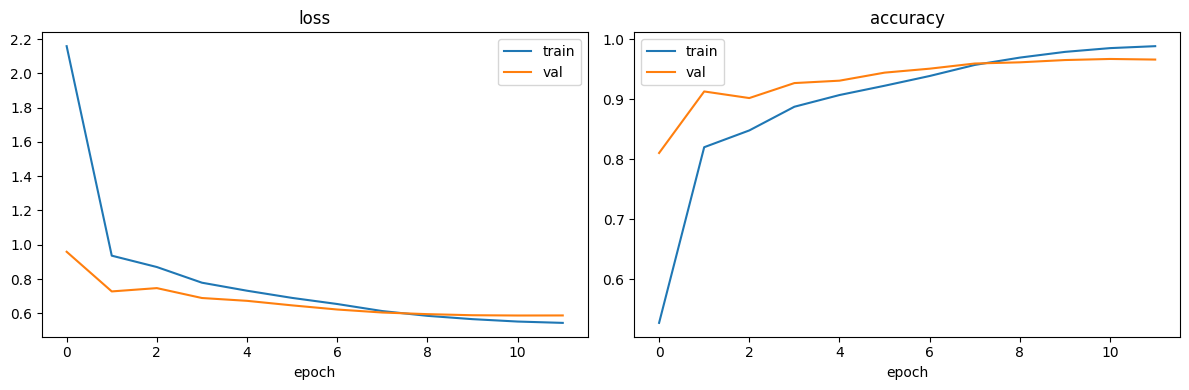

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history["train_loss"], label="train"); ax[0].plot(history["val_loss"], label="val")
ax[0].set_title("loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(history["train_acc"], label="train"); ax[1].plot(history["val_acc"], label="val")
ax[1].set_title("accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(CFG["out_dir"], "curves.png"), dpi=140)
plt.show()

loaded best.pt from epoch 11 (val acc 0.9670)
TEST  loss 0.5947   accuracy 0.9631
              precision    recall  f1-score   support

    airplane     0.9720    0.9730    0.9725      1000
  automobile     0.9723    0.9830    0.9776      1000
        bird     0.9697    0.9590    0.9643      1000
         cat     0.9213    0.9130    0.9171      1000
        deer     0.9576    0.9700    0.9637      1000
         dog     0.9330    0.9190    0.9259      1000
        frog     0.9734    0.9890    0.9812      1000
       horse     0.9809    0.9750    0.9779      1000
        ship     0.9723    0.9830    0.9776      1000
       truck     0.9778    0.9670    0.9723      1000

    accuracy                         0.9631     10000
   macro avg     0.9630    0.9631    0.9630     10000
weighted avg     0.9630    0.9631    0.9630     10000



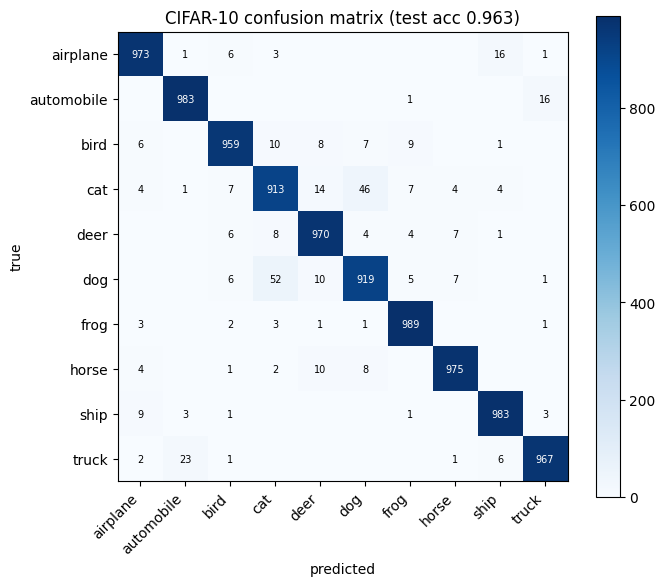

artifacts written to /content/drive/MyDrive/cisc3024_ai1/runs/mnv4_cifar10


In [28]:
from sklearn.metrics import confusion_matrix, classification_report

# best.pt now stores the full training state, so use safe_load (weights_only=False)
ckpt = safe_load(CKPT_BEST, map_location=device)
model.load_state_dict(ckpt["model"])
print(f"loaded best.pt from epoch {ckpt['epoch']} "
      f"(val acc {ckpt['best_acc']:.4f})")

test_loss, test_acc = evaluate(model, test_loader, criterion, device)
print(f"TEST  loss {test_loss:.4f}   accuracy {test_acc:.4f}")

model.eval()
ys, ps = [], []
with torch.no_grad():
    for images, targets in test_loader:
        with autocast_ctx():
            logits = model(images.to(device))
        ps.append(logits.argmax(1).cpu())
        ys.append(targets)
ys = torch.cat(ys).numpy()
ps = torch.cat(ps).numpy()

print(classification_report(ys, ps, target_names=CLASSES, digits=4))

cm = confusion_matrix(ys, ps)
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(10)); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
ax.set_yticks(range(10)); ax.set_yticklabels(CLASSES)
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title(f"CIFAR-10 confusion matrix (test acc {test_acc:.3f})")
for i in range(10):
    for j in range(10):
        if cm[i, j]:
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.colorbar(im); plt.tight_layout()
plt.savefig(os.path.join(CFG["out_dir"], "confusion_matrix.png"), dpi=140)
plt.show()

with open(os.path.join(CFG["out_dir"], "results.json"), "w") as f:
    json.dump({"test_acc": float(test_acc),
               "best_val_acc": float(best_acc),
               "epochs_run": len(history["train_loss"]),
               "history": history,
               "cfg": CFG}, f, indent=2)
print("artifacts written to", CFG["out_dir"])

## Stage 5 — Next steps for the report

1. **Error gallery.** Show the most confidently-wrong test images. Look for a
   pattern (e.g. cat/dog confusion) and name it as a failure mode.
2. **Baseline.** Re-run with `model_name = "resnet18"` or
   `"mobilenetv3_small_100"` so your number is anchored to something.
   Remember to change `out_dir` too, or the new run will overwrite your
   MobileNetV4 checkpoints.
3. **Ablations.** One variable at a time:
   * `img_size` 128 vs 224
   * freeze the backbone vs full fine-tune
   * RandAugment on vs off
   * `mobilenetv4_conv_small` vs `mobilenetv4_conv_medium`
4. **Cost table.** Record parameters, wall-clock per epoch and test accuracy for
   every run — this is the table that earns marks.
5. **Reproducibility.** Keep the pinned `timm` version, the seed and the exact
   `model_name` string in the report. Mention that checkpoints were written to
   Google Drive and that the pipeline supports resuming across Colab sessions.
